In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

In [7]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
df = pd.read_csv(
    "amazonreviews (1).tsv",
    sep='\t',
    quoting=3
)

In [10]:
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,"""Amazing!: This soundtrack is my favorite musi..."
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,"""A revelation of life in small town America in..."
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [11]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,"""Amazing!: This soundtrack is my favorite musi..."
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [12]:
df.columns

Index(['label', 'review'], dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [14]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [15]:
df.dropna(inplace=True)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df['label'].value_counts()

label
neg    5097
pos    4903
Name: count, dtype: int64

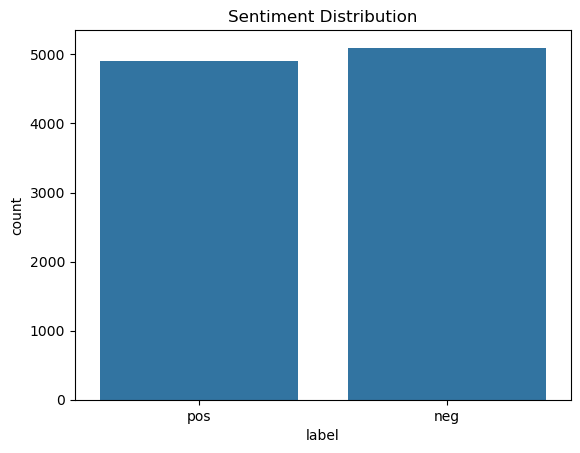

In [18]:
sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")

plt.show()

In [19]:
stop_words = set(stopwords.words('english'))

In [20]:
def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'\d+', '', text)
    
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    
    words = word_tokenize(text)
    
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [21]:
df.columns

Index(['label', 'review'], dtype='object')

In [26]:
df = df.dropna()

In [27]:
df['review'] = df['review'].astype(str)

In [28]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [30]:
import re
import string

from nltk.tokenize import word_tokenize

In [31]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [32]:
df['clean_review'] = df['review'].apply(clean_text)

In [33]:
df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,"""Amazing!: This soundtrack is my favorite musi...",amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [35]:
df[['clean_review']].head()

,clean_review
0,stuning even nongamer sound track beautiful pa...
1,best soundtrack ever anything im reading lot r...
2,amazing soundtrack favorite music time hands i...
3,excellent soundtrack truly like soundtrack enj...
4,remember pull jaw floor hearing youve played g...


In [36]:
df['label'] = df['label'].map({
    'pos': 1,
    'neg': 0
})

In [37]:
X = df['clean_review']

y = df['label']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [40]:
lr_model = LogisticRegression()

lr_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression()

In [41]:
y_pred_lr = lr_model.predict(
    X_test_tfidf
)

In [42]:
accuracy_score(y_test, y_pred_lr)

0.844

In [43]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1037
           1       0.83      0.85      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



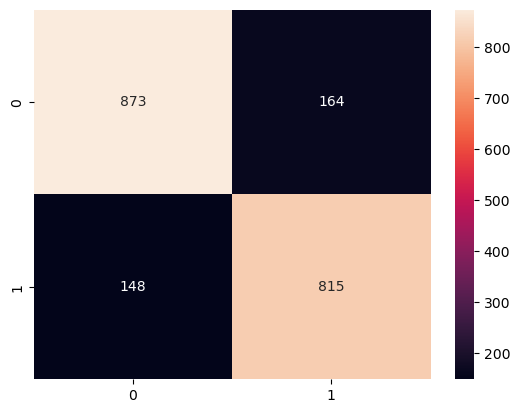

In [44]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [45]:
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

LinearSVC()

In [46]:
y_pred_svm = svm_model.predict(
    X_test_tfidf
)

In [47]:
accuracy_score(
    y_test,
    y_pred_svm
)

0.8415

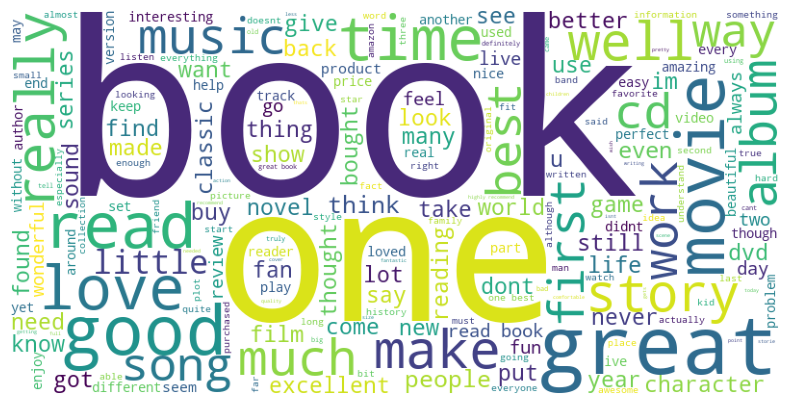

In [48]:
positive_text = " ".join(
    df[df['label'] == 1]['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

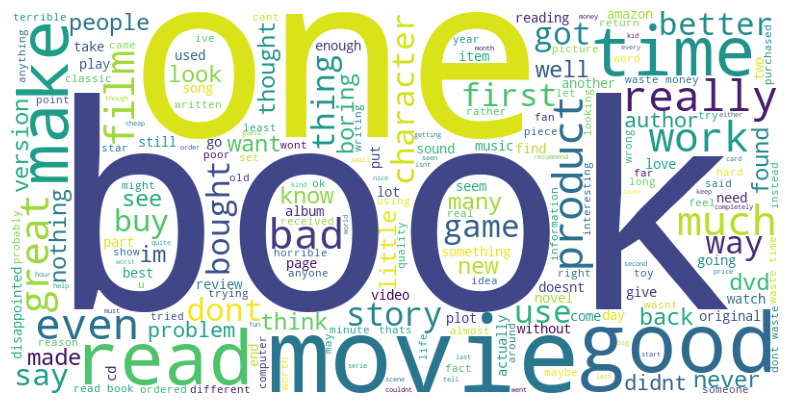

In [49]:
negative_text = " ".join(
    df[df['label'] == 0]['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [50]:
sample = [
    "This product is amazing"
]

sample_clean = [
    clean_text(text)
    for text in sample
]

sample_vector = tfidf.transform(sample_clean)

prediction = svm_model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review
